In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries loaded successfully")

Libraries loaded successfully


In [52]:
print("Libraries loaded successfully")

Libraries loaded successfully


Data input

In [53]:
from google.colab import files

uploaded = files.upload()

Saving diabetes1.csv to diabetes1 (2).csv


In [54]:
df = pd.read_csv("diabetes1.csv")

In [55]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [56]:
df.shape

(768, 9)

All description about the data



In [57]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.435949,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [58]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.435949,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Check missing values

In [59]:
df.isnull().sum()


,0
Pregnancies,0
Glucose,0
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Check zero values

In [60]:
zero_counts = (df == 0).sum()

print(zero_counts)

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


Check zero values

In [61]:
df.duplicated().sum()

np.int64(0)

Check duplicate rows

In [62]:
df[df.duplicated()]
df = df.drop_duplicates()

Handle missing values

In [63]:
columns_with_missing = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

df[columns_with_missing] = df[columns_with_missing].replace(0, np.nan)

In [64]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [65]:
zero_counts = (df == 0).sum()

print(zero_counts)

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


Check for impossible values

In [66]:
print(df['Age'].min())
print(df['Age'].max())
print(df['BMI'].min())
print(df['BMI'].max())
print(df['Glucose'].min())
print(df['Glucose'].max())

21
81
18.2
67.1
44.0
199.0


First visualization: Missing values

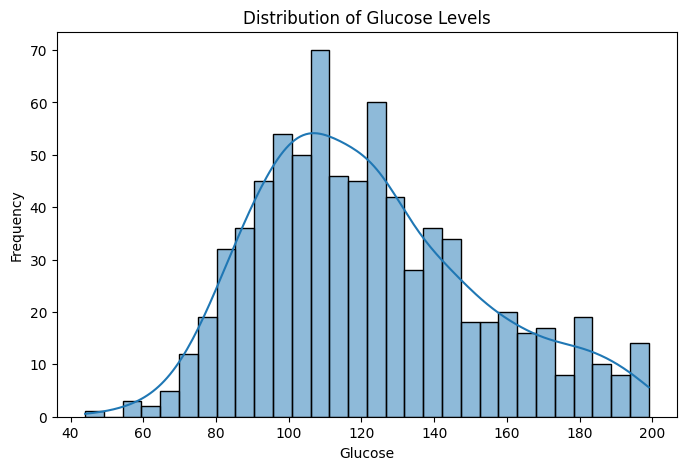

In [67]:
plt.figure(figsize=(8, 5))

sns.histplot(df['Glucose'], bins=30, kde=True)

plt.title("Distribution of Glucose Levels")
plt.xlabel("Glucose")
plt.ylabel("Frequency")

plt.show()

Visualization 2: Glucose distribution

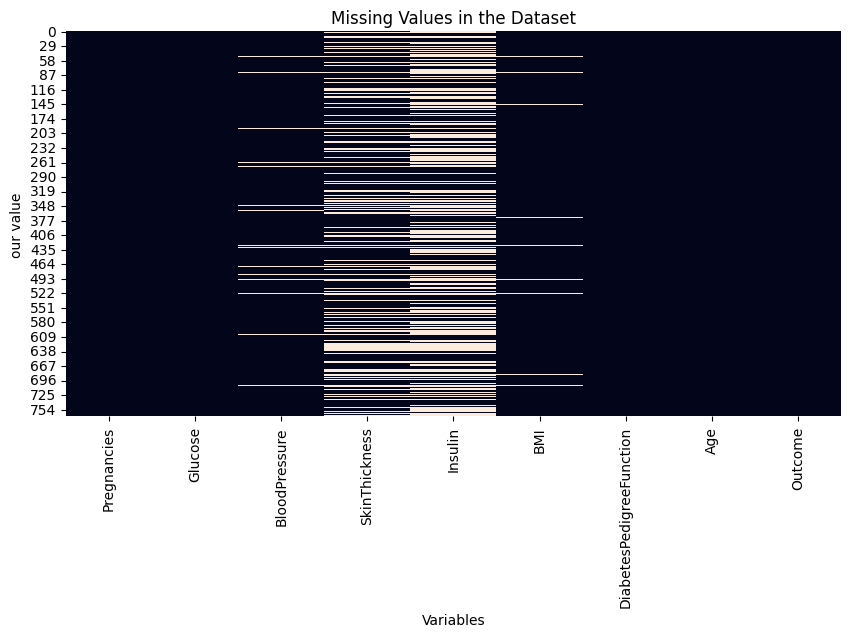

In [68]:
plt.figure(figsize=(10, 5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values in the Dataset")
plt.xlabel("Variables")
plt.ylabel("our value")

plt.show()

Visualization 3: Diabetes outcome

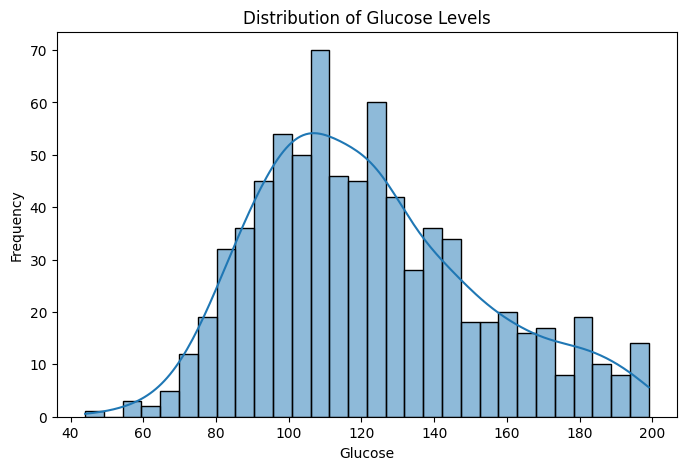

In [69]:
plt.figure(figsize=(8, 5))

sns.histplot(df['Glucose'], bins=30, kde=True)

plt.title("Distribution of Glucose Levels")
plt.xlabel("Glucose")
plt.ylabel("Frequency")

plt.show()

Visualization 4: Glucose vs diabetes

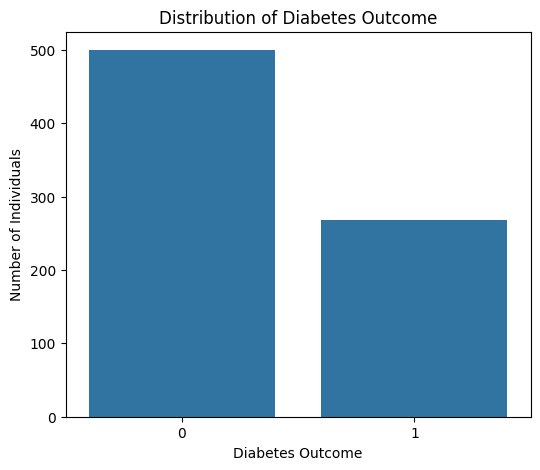

In [70]:
plt.figure(figsize=(6, 5))

sns.countplot(data=df, x='Outcome')

plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Diabetes Outcome")
plt.ylabel("Number of Individuals")

plt.show()

Visualization 5: BMI vs glucose

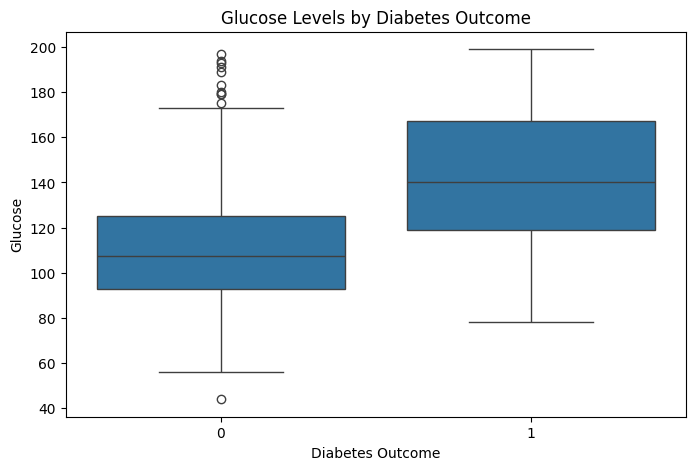

In [71]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Outcome', y='Glucose')

plt.title("Glucose Levels by Diabetes Outcome")
plt.xlabel("Diabetes Outcome")
plt.ylabel("Glucose")

plt.show()

Visualization 6: Correlation heatmap

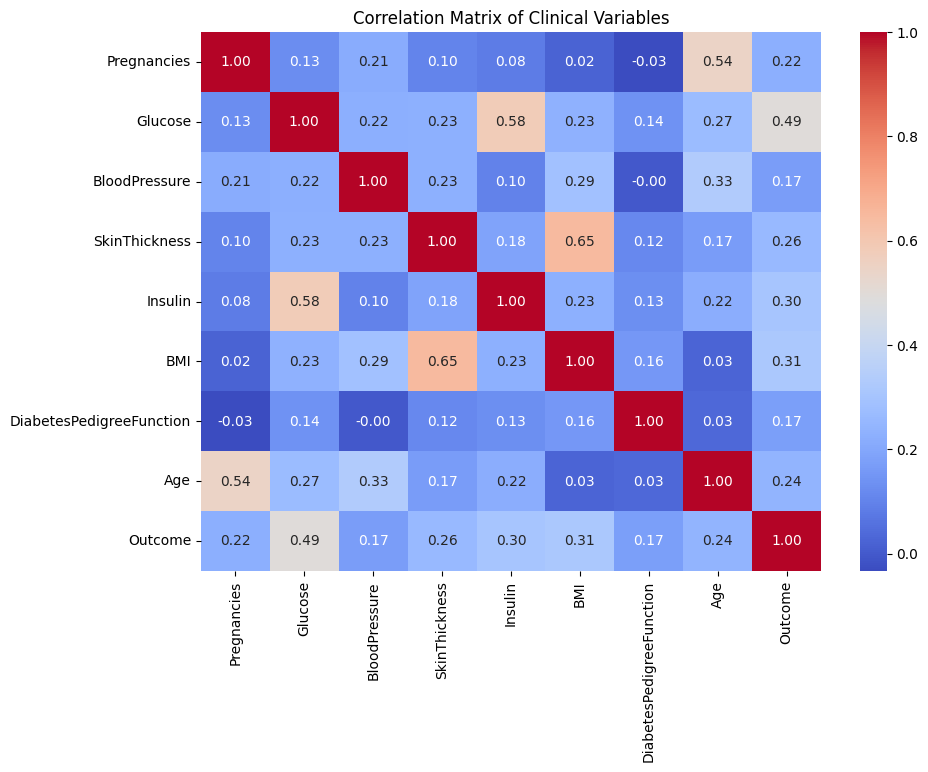

In [73]:
plt.figure(figsize=(10, 7))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix of Clinical Variables")

plt.show()

Group statistics

In [74]:
df.groupby('Outcome')['Glucose'].mean()
df.groupby('Outcome')[['Glucose', 'BMI', 'Age']].mean()


,Glucose,BMI,Age
Outcome,,,
0,110.710121,30.859674,31.190000
1,142.165573,35.406767,37.067164


Count the groups

In [75]:
df.to_csv("diabetes1.csv", index=False)

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Python is working")

Python is working
